# Feature Engineering for Denial Prediction

Builds and validates the feature set used by `ml/train_model.py`:
derivations, encodings, target relationships, and leakage checks.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('../data/synthetic/claims_50k.csv', parse_dates=['claim_date', 'service_date'])
print(f'{len(df):,} claims loaded')

50,000 claims loaded


## 1. Derived features
- `icd10_chapter` — first 3 chars of the ICD-10 code (category level)
- `claim_month`, `claim_quarter` — seasonality signals
- booleans cast to int for XGBoost

In [2]:
df['icd10_chapter'] = df['icd10_primary'].str[:3]
df['claim_month'] = df['claim_date'].dt.month
df['claim_quarter'] = df['claim_date'].dt.quarter
df['prior_auth_required'] = df['prior_auth_required'].astype(int)
df['prior_auth_obtained'] = df['prior_auth_obtained'].astype(int)
df['auth_missing'] = ((df['prior_auth_required'] == 1) & (df['prior_auth_obtained'] == 0)).astype(int)

CATEGORICAL = ['payer_type', 'provider_type', 'icd10_chapter', 'cpt_code',
               'patient_age_bucket', 'place_of_service', 'state']
NUMERIC = ['prior_auth_required', 'prior_auth_obtained', 'claim_amount',
           'claim_month', 'claim_quarter']
TARGET = 'denial_flag'
df[CATEGORICAL + NUMERIC + [TARGET]].head()

,payer_type,provider_type,icd10_chapter,cpt_code,patient_age_bucket,place_of_service,state,prior_auth_required,prior_auth_obtained,claim_amount,claim_month,claim_quarter,denial_flag
0,medicare,specialist,N39,99232,50-64,21,CA,1,1,299.49,2,1,0
1,self_pay,imaging,M54,64483,50-64,21,MO,1,1,1542.51,6,2,0
2,medicare,hospital,F32,99213,65+,23,TN,0,0,116.99,11,4,0
3,commercial,hospital,C50,99214,50-64,11,MI,0,0,258.50,5,2,0
4,commercial,physician,E78,64483,50-64,11,TX,1,1,1778.92,8,3,0


## 2. Leakage check
Columns like `claim_status`, `denial_reason_code`, `allowed_amount`, and `paid_amount`
are **post-adjudication** — they encode the outcome and must never enter the model.
The feature list above contains only fields known **at submission time**.

In [3]:
post_adjudication = ['claim_status', 'denial_reason_code', 'denial_reason_description',
                     'allowed_amount', 'paid_amount']
overlap = set(post_adjudication) & set(CATEGORICAL + NUMERIC)
assert not overlap, f'LEAKAGE: {overlap}'
print('No leakage: feature set is strictly pre-submission.')

No leakage: feature set is strictly pre-submission.


## 3. Feature-target relationships

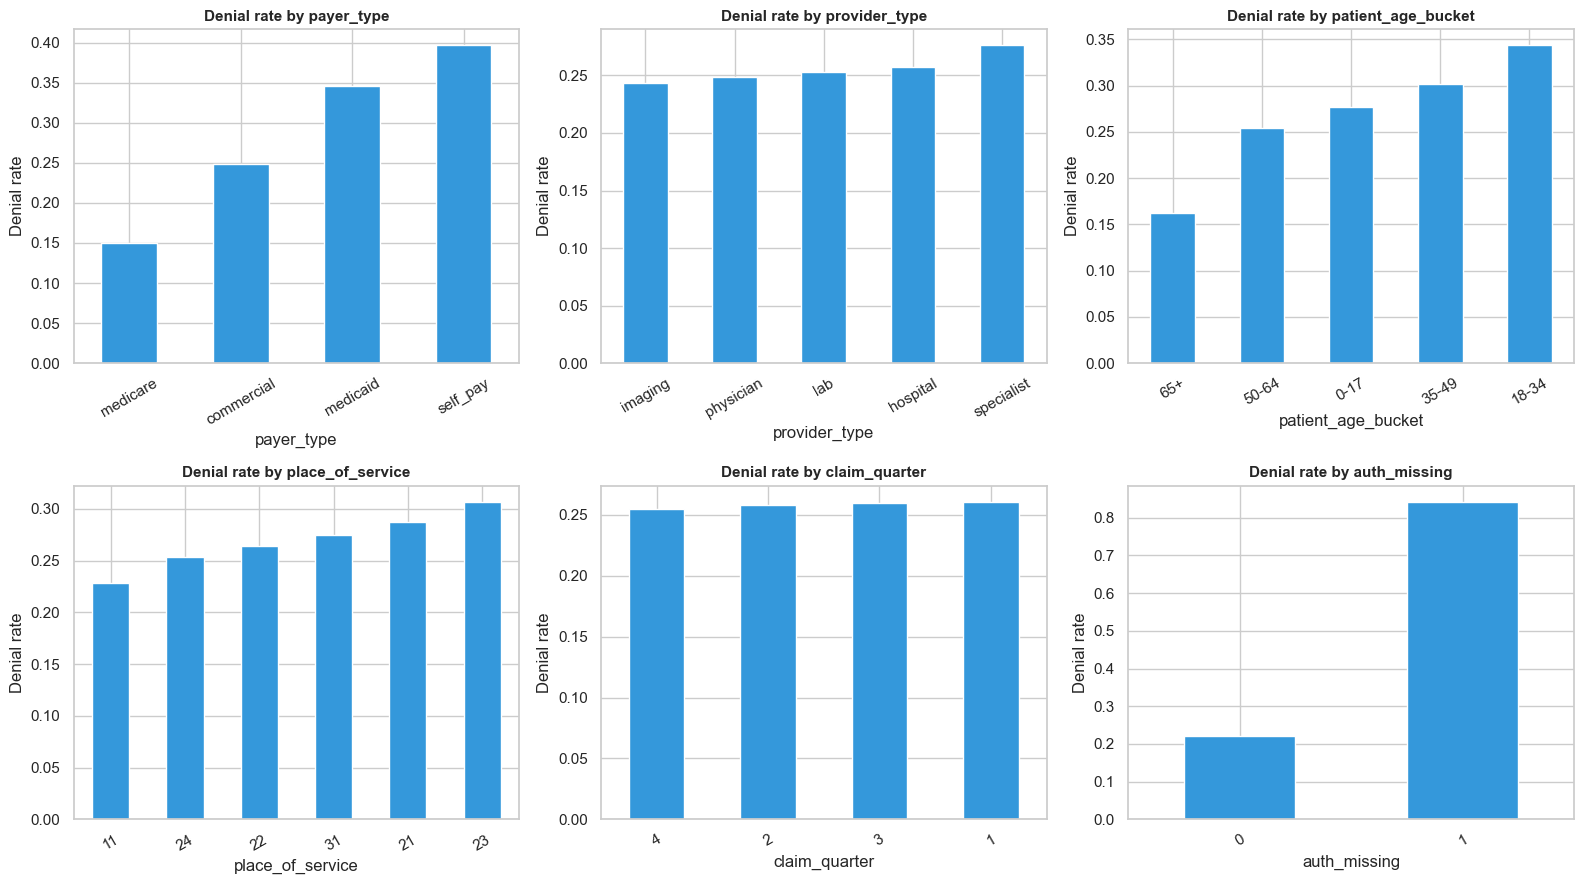

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, ['payer_type', 'provider_type', 'patient_age_bucket',
                               'place_of_service', 'claim_quarter', 'auth_missing']):
    rates = df.groupby(col)[TARGET].mean().sort_values()
    rates.plot(kind='bar', ax=ax, color='#3498db')
    ax.set_title(f'Denial rate by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Denial rate')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

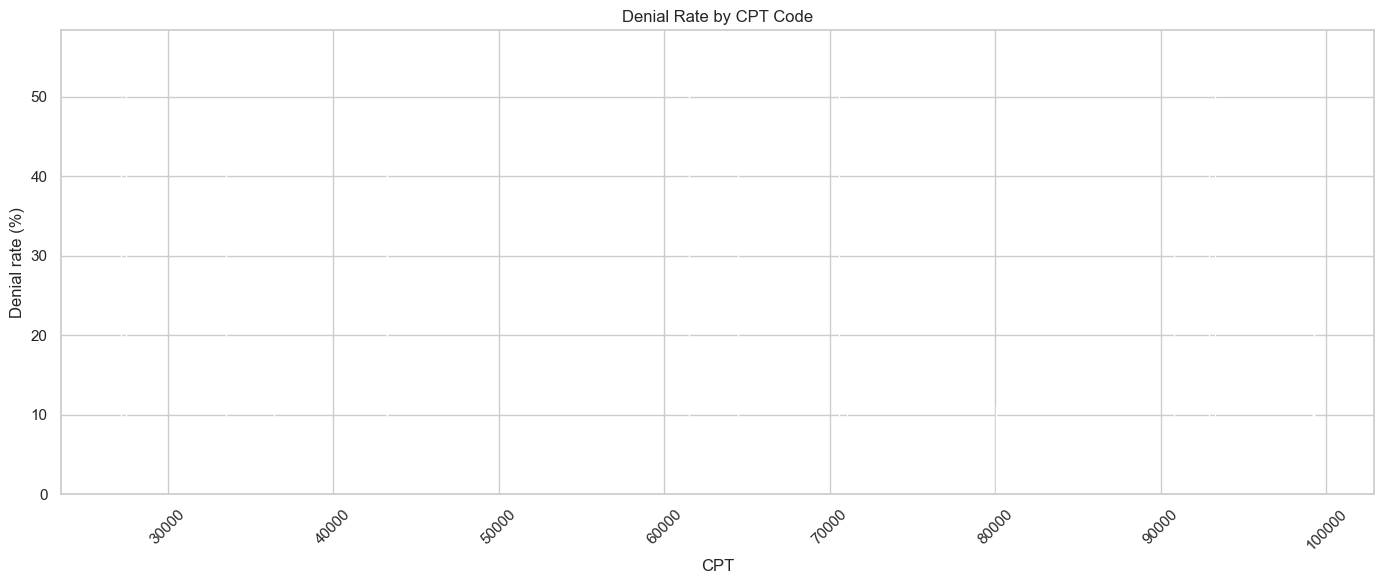

CPT denial-rate spread: 10.5% to 55.6%


In [5]:
# CPT-level denial rates — wide spread confirms cpt_code is a strong feature
cpt_rates = df.groupby('cpt_code')[TARGET].agg(['mean', 'size']).sort_values('mean')
fig, ax = plt.subplots()
ax.bar(cpt_rates.index, cpt_rates['mean'] * 100, color='#9b59b6')
ax.set_title('Denial Rate by CPT Code')
ax.set_ylabel('Denial rate (%)'); ax.set_xlabel('CPT')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(f"CPT denial-rate spread: {cpt_rates['mean'].min():.1%} to {cpt_rates['mean'].max():.1%}")

## 4. Encoding strategy
Label encoding per categorical column (tree models split on category indices natively;
one-hot would explode `state`/`cpt_code` cardinality for no benefit). Encoders are
fit on the full feature frame and persisted to `ml/artifacts/encoders.pkl` so the
Streamlit scorer encodes inference rows identically; unseen categories map to -1.

In [6]:
from sklearn.preprocessing import LabelEncoder

X = df[CATEGORICAL + NUMERIC].copy()
encoders = {}
for col in CATEGORICAL:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
y = df[TARGET]

print('Encoded feature matrix:')
print(X.dtypes)
X.head()

Encoded feature matrix:
payer_type               int64
provider_type            int64
icd10_chapter            int64
cpt_code                 int64
patient_age_bucket       int64
place_of_service         int64
state                    int64
prior_auth_required      int64
prior_auth_obtained      int64
claim_amount           float64
claim_month              int32
claim_quarter            int32
dtype: object


,payer_type,provider_type,icd10_chapter,cpt_code,patient_age_bucket,place_of_service,state,prior_auth_required,prior_auth_obtained,claim_amount,claim_month,claim_quarter
0,2,4,16,17,3,1,4,1,1,299.49,2,1
1,3,1,14,8,3,1,21,1,1,1542.51,6,2
2,2,0,3,15,4,3,38,0,0,116.99,11,4
3,0,0,0,16,3,0,19,0,0,258.50,5,2
4,0,3,2,8,3,0,39,1,1,1778.92,8,3


## 5. Quick signal check
A shallow untuned tree gives a fast read on whether the features carry signal
before committing to the full hyperparameter search in `ml/train_model.py`.

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

quick = HistGradientBoostingClassifier(max_depth=4, random_state=42)
scores = cross_val_score(quick, X, y, cv=3, scoring='roc_auc')
print(f'Quick-check AUC: {scores.mean():.4f} (+/- {scores.std():.4f})')
print('Full tuned XGBoost training lives in ml/train_model.py')

Quick-check AUC: 0.8314 (+/- 0.0034)
Full tuned XGBoost training lives in ml/train_model.py
